# TTR vs. LLM-judge degeneration labels

This notebook evaluates two token-level TTR decision rules against the LLM judge for each of the three dataset builds. The primary population is the set of rollouts that reached the 4096-token generation cap without a natural EOS.
Two questions are evaluated:

1. **Basic single-token rule:** a generation is degenerating if it contains at least one token with `repetition_score >= 0.8`; onset is the first such token.
2. **Sustained run-4 rule:** a generation is degenerating if it contains four consecutive tokens at or above the same threshold; onset is the first token of the first qualifying run.
3. **Comparison with the judge:** for each rule, measure completion-level detection and signed onset distance, then compare the two rules directly.

The notebook is read-only with respect to the datasets.

## 1. Definitions

Let $r_t$ be the stored token-level `repetition_score`, computed by the labeling pipeline as $1-\mathrm{TTR}$ over bigrams in the 256-token window beginning at token $t$.

A token position is threshold-positive when

$$r_t \geq \tau, \qquad \tau=0.8.$$

The **basic single-token rule** defines

$$o_1 = \min\left\{t:r_t\geq0.8\right\}, \qquad y_1=\mathbb{I}[o_1\text{ exists}].$$

The **sustained run-4 rule** defines

$$o_4 = \min\left\{t:r_t,r_{t+1},r_{t+2},r_{t+3}\geq0.8\right\}, \qquad y_4=\mathbb{I}[o_4\text{ exists}].$$

Undefined (`NaN`) scores are never threshold-positive and break a run. By construction, $y_4=1$ implies $y_1=1$, and whenever $o_4$ exists, $o_1\leq o_4$.

The LLM-judge binary reference is `is_degenerating`. For judge-positive completions, the judge onset $o_{\mathrm{LLM}}$ is the first generated-token position of the verbatim `onset_quote`. Quotes that cannot be located exactly are excluded from onset-distance statistics, but the corresponding binary verdict remains valid for completion-level detection.

The signed onset distance is defined as

$$d_j = o_{\mathrm{LLM}} - o_j, \qquad j\in\{1,4\}.$$

Thus $d_j>0$ means that the LLM judge places onset later than TTR, while $d_j<0$ means that the judge places onset earlier. Onset distance is only defined when the judge is positive, its quote is matched, and the corresponding TTR rule is positive.

In [1]:
import os
from pathlib import Path
import warnings

# The Apertus-8B tokenizer is already cached by dataset generation. Use the
# shared cache in offline mode so this notebook does not require network access.
SHARED_HF_CACHE = Path("/capstor/scratch/cscs/mdenegri/degeneration-probe/hf_cache")
if SHARED_HF_CACHE.exists():
    os.environ.setdefault("HF_HOME", str(SHARED_HF_CACHE))
    os.environ.setdefault("HF_HUB_CACHE", str(SHARED_HF_CACHE))
os.environ.setdefault("HF_HUB_OFFLINE", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from transformers import AutoTokenizer

from degeneration_probe.utils.tokenization import find_string_in_tokens

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

DATA_ROOT = Path("/capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe")
DATASETS = {
    "Apertus-8B-Instruct": {
        "root": DATA_ROOT / "degeneration-dataset-apertus-8b-instruct",
        "tokenizer": "swiss-ai/Apertus-8B-Instruct-2509",
    },
    "Apertus 1.5 - capfilter-linear": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-capfilter-linear-it8816",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
    "Apertus 1.5 - SFT-256k": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-sft256k-4200",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
}

JUDGE_BACKEND = "claude_agent_sdk"
TTR_THRESHOLD = 0.8
MIN_CONSECUTIVE = 4
EXPECTED_MAX_TOKENS = 4096
KEY = ["prompt_id", "rollout_idx"]

W0721 10:38:21.819000 49479 /iopsstor/scratch/cscs/sartoril/degeneration-probe/.venv/lib/python3.11/site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0721 10:38:21.948000 49479 /iopsstor/scratch/cscs/sartoril/degeneration-probe/.venv/lib/python3.11/site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


## 2. Load and validate the current truncated-rollout sample

Judge result files may retain successfully judged rows from an older calibration sample. To avoid mixing populations, the analysis starts from the current `calibration_sample.parquet`, keeps only `stratum == "truncated"`, and inner-joins current successful judge results. It then joins generation and TTR-label shards by `(prompt_id, rollout_idx)`.

In [2]:
def read_domain_shards(root, kind, columns):
    frames = []
    for path in sorted((root / kind).glob("*/shard_*.parquet")):
        frame = pd.read_parquet(path, columns=columns)
        frame["shard_domain"] = path.parent.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No {kind} shards found below {root}")
    return pd.concat(frames, ignore_index=True)


def load_evaluation_population(root):
    sample_path = root / "llm_judge/calibration_sample.parquet"
    judge_path = root / f"llm_judge/results_{JUDGE_BACKEND}.parquet"

    sample = pd.read_parquet(sample_path)
    sample = sample[sample["stratum"].eq("truncated")].copy()
    judge_all = pd.read_parquet(judge_path)
    judge = judge_all[judge_all["status"].eq("ok")].copy()

    assert not sample.duplicated(KEY).any(), "Duplicate keys in current calibration sample"
    assert not judge.duplicated(KEY).any(), "Duplicate keys in successful judge results"

    # Starting from the current sample deliberately drops stale judge rows.
    population = sample.merge(
        judge[KEY + ["is_degenerating", "onset_quote", "confidence"]],
        on=KEY, how="inner", validate="one_to_one",
    )

    generations = read_domain_shards(
        root, "generations",
        KEY + ["generated_token_ids", "num_tokens", "stop_reason"],
    )
    labels = read_domain_shards(root, "labels", KEY + ["repetition_score"])
    assert not generations.duplicated(KEY).any(), "Duplicate generation keys"
    assert not labels.duplicated(KEY).any(), "Duplicate label keys"

    population = population.merge(
        generations[KEY + ["generated_token_ids", "num_tokens", "stop_reason"]],
        on=KEY, how="left", validate="one_to_one",
    ).merge(
        labels[KEY + ["repetition_score"]],
        on=KEY, how="left", validate="one_to_one",
    )

    assert population["generated_token_ids"].notna().all(), "Missing generation rows"
    assert population["repetition_score"].notna().all(), "Missing TTR label rows"
    assert population["stop_reason"].eq("length").all(), "Sample contains a natural EOS rollout"
    assert population["num_tokens"].eq(EXPECTED_MAX_TOKENS).all(), "Sample contains a non-4096-token rollout"
    assert all(
        len(ids) == len(scores) == n
        for ids, scores, n in zip(
            population["generated_token_ids"],
            population["repetition_score"],
            population["num_tokens"],
        )
    ), "Token IDs and TTR labels are not aligned"

    coverage = {
        "sample_truncated": len(sample),
        "judge_ok_in_current_sample": len(population),
        "judge_coverage": len(population) / len(sample) if len(sample) else np.nan,
        "stale_or_other_judge_ok_excluded": len(judge) - len(population),
    }
    return population, coverage


populations = {}
coverage_rows = []
for model, spec in DATASETS.items():
    population, coverage = load_evaluation_population(spec["root"])
    populations[model] = population
    coverage_rows.append({"dataset_build": model, **coverage})

coverage_df = pd.DataFrame(coverage_rows).set_index("dataset_build")
display(coverage_df.style.format({"judge_coverage": "{:.1%}"}))

,sample_truncated,judge_ok_in_current_sample,judge_coverage,stale_or_other_judge_ok_excluded
dataset_build,,,,
Apertus-8B-Instruct,890,827,92.9%,343
Apertus 1.5 - capfilter-linear,1348,1278,94.8%,1559
Apertus 1.5 - SFT-256k,1193,1111,93.1%,0


## 3. Sustained run-4 TTR: completion-level study

The implementation below returns the first start index of four consecutive finite scores greater than or equal to 0.8. A completion is flagged exactly when this onset is defined.

In [3]:
def first_ttr_run_onset(scores, threshold=TTR_THRESHOLD, min_consecutive=MIN_CONSECUTIVE):
    values = np.asarray(scores, dtype=float)
    above = np.isfinite(values) & (values >= threshold)
    if len(above) < min_consecutive:
        return None
    run_lengths = np.convolve(
        above.astype(np.int8),
        np.ones(min_consecutive, dtype=np.int8),
        mode="valid",
    )
    starts = np.flatnonzero(run_lengths == min_consecutive)
    return int(starts[0]) if len(starts) else None


# Small deterministic checks, including equality at the threshold and a NaN break.
assert first_ttr_run_onset([0.1, 0.8, 0.9, 0.8, 1.0, 0.2]) == 1
assert first_ttr_run_onset([0.8, 0.9, np.nan, 0.9, 0.9, 0.9, 0.9]) == 3
assert first_ttr_run_onset([0.8, 0.8, 0.8, 0.79]) is None

for model, population in populations.items():
    population["ttr_run4_onset"] = population["repetition_score"].apply(first_ttr_run_onset)
    population["ttr_run4_flag"] = population["ttr_run4_onset"].notna()
    population["is_degenerating"] = population["is_degenerating"].astype(bool)
    print(
        f"{model}: {population['ttr_run4_flag'].sum()}/{len(population)} "
        f"TTR-positive ({population['ttr_run4_flag'].mean():.1%})"
    )

Apertus-8B-Instruct: 245/827 TTR-positive (29.6%)
Apertus 1.5 - capfilter-linear: 795/1278 TTR-positive (62.2%)
Apertus 1.5 - SFT-256k: 451/1111 TTR-positive (40.6%)


### 3.1 Completion-level detection

TTR is the prediction and the LLM judge is the reference. A true positive is therefore a rollout flagged by both. Precision answers: *when TTR flags a capped rollout, how often does the judge agree?* Recall answers: *among capped rollouts judged degenerating, how often does the sustained TTR rule flag them?*

In [4]:
def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def binary_metrics(frame, prediction_column):
    truth = frame["is_degenerating"].to_numpy(dtype=bool)
    pred = frame[prediction_column].to_numpy(dtype=bool)
    tp = int(np.sum(pred & truth))
    fp = int(np.sum(pred & ~truth))
    tn = int(np.sum(~pred & ~truth))
    fn = int(np.sum(~pred & truth))
    precision = safe_ratio(tp, tp + fp)
    recall = safe_ratio(tp, tp + fn)
    return {
        "n": len(frame), "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "judge_positive_rate": truth.mean(),
        "ttr_positive_rate": pred.mean(),
        "precision": precision,
        "recall": recall,
        "f1": safe_ratio(2 * precision * recall, precision + recall),
        "specificity": safe_ratio(tn, tn + fp),
        "accuracy": safe_ratio(tp + tn, len(frame)),
    }


completion_rows = []
for model, population in populations.items():
    completion_rows.append({
        "dataset_build": model, **binary_metrics(population, "ttr_run4_flag"),
    })
run4_completion_metrics_df = pd.DataFrame(completion_rows).set_index("dataset_build")

metric_columns = [
    "n", "TP", "FP", "TN", "FN", "judge_positive_rate",
    "ttr_positive_rate", "precision", "recall", "f1", "specificity", "accuracy",
]
display(run4_completion_metrics_df[metric_columns].style.format({
    "judge_positive_rate": "{:.3f}", "ttr_positive_rate": "{:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
    "specificity": "{:.3f}", "accuracy": "{:.3f}",
}))

,n,TP,FP,TN,FN,judge_positive_rate,ttr_positive_rate,precision,recall,f1,specificity,accuracy
dataset_build,,,,,,,,,,,,
Apertus-8B-Instruct,827,245,0,8,574,0.990,0.296,1.000,0.299,0.461,1.000,0.306
Apertus 1.5 - capfilter-linear,1278,795,0,6,477,0.995,0.622,1.000,0.625,0.769,1.000,0.627
Apertus 1.5 - SFT-256k,1111,450,1,77,583,0.930,0.406,0.998,0.436,0.606,0.987,0.474


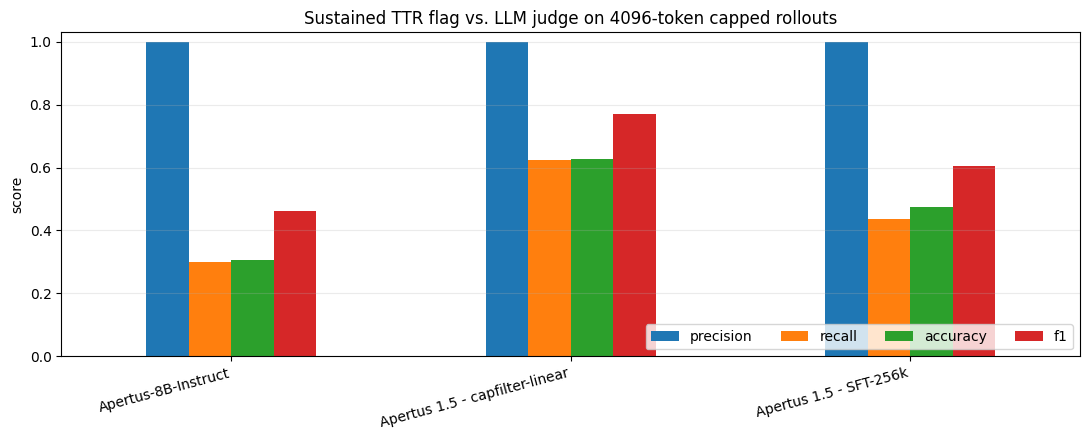

In [5]:
plot_metrics = ["precision", "recall", "accuracy", "f1"]
ax = run4_completion_metrics_df[plot_metrics].plot.bar(figsize=(11, 4.5), ylim=(0, 1.03))
ax.set_ylabel("score")
ax.set_xlabel("")
ax.set_title("Sustained TTR flag vs. LLM judge on 4096-token capped rollouts")
ax.legend(loc="lower right", ncol=4)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### 3.2 Per-domain run-4 completion-level results

Domain-level rows with very few judge-negative examples can have unstable precision or specificity. The counts are shown alongside the metrics so that these cases remain visible.

In [6]:
domain_completion_rows = []
for model, population in populations.items():
    for domain, group in population.groupby("domain", sort=True):
        domain_completion_rows.append({
            "dataset_build": model, "domain": domain,
            **binary_metrics(group, "ttr_run4_flag"),
        })
run4_domain_completion_df = pd.DataFrame(domain_completion_rows).set_index(["dataset_build", "domain"])
display(run4_domain_completion_df[["n", "TP", "FP", "TN", "FN", "precision", "recall", "accuracy"]].style.format({
    "precision": "{:.3f}", "recall": "{:.3f}", "accuracy": "{:.3f}",
}))

## 4. Locate LLM-judge onset quotes once for both studies

The quote is searched in the original generated token IDs using the tokenizer associated with each model build. The resulting token index is directly comparable with the index of `repetition_score`, because both are aligned to `generated_token_ids`.

In [7]:
_tokenizer_cache = {}


def get_tokenizer(name):
    if name not in _tokenizer_cache:
        kwargs = {"local_files_only": True}
        if not Path(name).exists() and SHARED_HF_CACHE.exists():
            kwargs["cache_dir"] = str(SHARED_HF_CACHE)
        _tokenizer_cache[name] = AutoTokenizer.from_pretrained(name, **kwargs)
    return _tokenizer_cache[name]


def locate_onset_quote(quote, generated_token_ids, tokenizer):
    if not isinstance(quote, str) or not quote:
        return np.nan
    tokens = torch.as_tensor([int(token) for token in generated_token_ids])
    try:
        return int(find_string_in_tokens(quote, tokens, tokenizer).start)
    except (AssertionError, ValueError):
        return np.nan


quote_coverage_rows = []
for model, population in populations.items():
    tokenizer = get_tokenizer(DATASETS[model]["tokenizer"])
    positive = population["is_degenerating"]
    population["llm_onset"] = np.nan
    population.loc[positive, "llm_onset"] = [
        locate_onset_quote(quote, token_ids, tokenizer)
        for quote, token_ids in zip(
            population.loc[positive, "onset_quote"],
            population.loc[positive, "generated_token_ids"],
        )
    ]
    n_positive = int(positive.sum())
    n_quote_present = int(population.loc[positive, "onset_quote"].notna().sum())
    n_quote_matched = int(population.loc[positive, "llm_onset"].notna().sum())
    quote_coverage_rows.append({
        "dataset_build": model,
        "judge_positive": n_positive,
        "quote_present": n_quote_present,
        "quote_matched": n_quote_matched,
        "match_rate_among_judge_positive": safe_ratio(n_quote_matched, n_positive),
    })

quote_coverage_df = pd.DataFrame(quote_coverage_rows).set_index("dataset_build")
display(quote_coverage_df.style.format({"match_rate_among_judge_positive": "{:.1%}"}))

,judge_positive,quote_present,quote_matched,match_rate_among_judge_positive
dataset_build,,,,
Apertus-8B-Instruct,819,819,818,99.9%
Apertus 1.5 - capfilter-linear,1272,1272,1270,99.8%
Apertus 1.5 - SFT-256k,1033,1033,1033,100.0%


## 5. Basic single-token TTR study

This is the direct interpretation of a token-level score: a token is degenerating when `repetition_score >= 0.8`; a generation is degenerating if and only if it contains at least one such token; onset is the first threshold-positive token. Equivalently, this is the same run detector used above with `min_consecutive=1`.

In [8]:
# Boundary and masking checks for the basic rule.
assert first_ttr_run_onset([0.1, 0.8, 0.9], min_consecutive=1) == 1
assert first_ttr_run_onset([np.nan, 0.79, 0.81], min_consecutive=1) == 2
assert first_ttr_run_onset([np.nan, 0.79], min_consecutive=1) is None

single_completion_rows = []
single_domain_rows = []
for model, population in populations.items():
    population["ttr_single_onset"] = population["repetition_score"].apply(
        lambda scores: first_ttr_run_onset(scores, min_consecutive=1)
    )
    population["ttr_single_flag"] = population["ttr_single_onset"].notna()
    single_completion_rows.append({
        "dataset_build": model, **binary_metrics(population, "ttr_single_flag"),
    })
    for domain, group in population.groupby("domain", sort=True):
        single_domain_rows.append({
            "dataset_build": model, "domain": domain,
            **binary_metrics(group, "ttr_single_flag"),
        })

single_completion_metrics_df = pd.DataFrame(single_completion_rows).set_index("dataset_build")
single_domain_completion_df = pd.DataFrame(single_domain_rows).set_index(["dataset_build", "domain"])

print("Completion-level metrics: basic single-token rule")
display(single_completion_metrics_df[metric_columns].style.format({
    "judge_positive_rate": "{:.3f}", "ttr_positive_rate": "{:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
    "specificity": "{:.3f}", "accuracy": "{:.3f}",
}))

print("Per-domain completion-level metrics: basic single-token rule")
display(single_domain_completion_df[[
    "n", "TP", "FP", "TN", "FN", "precision", "recall", "accuracy",
]].style.format({"precision": "{:.3f}", "recall": "{:.3f}", "accuracy": "{:.3f}"}))

Completion-level metrics: basic single-token rule


,n,TP,FP,TN,FN,judge_positive_rate,ttr_positive_rate,precision,recall,f1,specificity,accuracy
dataset_build,,,,,,,,,,,,
Apertus-8B-Instruct,827,246,0,8,573,0.990,0.297,1.000,0.300,0.462,1.000,0.307
Apertus 1.5 - capfilter-linear,1278,797,0,6,475,0.995,0.624,1.000,0.627,0.770,1.000,0.628
Apertus 1.5 - SFT-256k,1111,451,1,77,582,0.930,0.407,0.998,0.437,0.607,0.987,0.475


Per-domain completion-level metrics: basic single-token rule


In [9]:
single_onset_frames = []
single_onset_rows = []
for model, population in populations.items():
    comparable = population[
        population["is_degenerating"]
        & population["llm_onset"].notna()
        & population["ttr_single_onset"].notna()
    ].copy()
    comparable["signed_distance"] = comparable["llm_onset"] - comparable["ttr_single_onset"]
    comparable["absolute_distance"] = comparable["signed_distance"].abs()
    comparable["dataset_build"] = model
    single_onset_frames.append(comparable)

    d = comparable["signed_distance"]
    a = comparable["absolute_distance"]
    single_onset_rows.append({
        "dataset_build": model,
        "n_comparable": len(comparable),
        "mean_signed_distance": d.mean(),
        "median_signed_distance": d.median(),
        "mean_absolute_distance": a.mean(),
        "median_absolute_distance": a.median(),
        "q25_signed": d.quantile(0.25),
        "q75_signed": d.quantile(0.75),
        "judge_earlier_rate": (d < 0).mean(),
        "exact_rate": (d == 0).mean(),
        "judge_later_rate": (d > 0).mean(),
        "within_32_tokens": (a <= 32).mean(),
        "within_64_tokens": (a <= 64).mean(),
        "within_128_tokens": (a <= 128).mean(),
    })

single_onset_comparisons_df = pd.concat(single_onset_frames, ignore_index=True)
single_onset_summary_df = pd.DataFrame(single_onset_rows).set_index("dataset_build")
single_domain_onset_df = (
    single_onset_comparisons_df.groupby(["dataset_build", "domain"])["signed_distance"]
    .agg(
        n="size",
        mean_signed_distance="mean",
        median_signed_distance="median",
        mean_absolute_distance=lambda x: x.abs().mean(),
        median_absolute_distance=lambda x: x.abs().median(),
    )
)

print("Onset-distance metrics: basic single-token rule")
display(single_onset_summary_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
    "q25_signed": "{:.1f}", "q75_signed": "{:.1f}",
    "judge_earlier_rate": "{:.1%}", "exact_rate": "{:.1%}",
    "judge_later_rate": "{:.1%}", "within_32_tokens": "{:.1%}",
    "within_64_tokens": "{:.1%}", "within_128_tokens": "{:.1%}",
}))
print("Per-domain onset metrics: basic single-token rule")
display(single_domain_onset_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
}))

Onset-distance metrics: basic single-token rule


,n_comparable,mean_signed_distance,median_signed_distance,mean_absolute_distance,median_absolute_distance,q25_signed,q75_signed,judge_earlier_rate,exact_rate,judge_later_rate,within_32_tokens,within_64_tokens,within_128_tokens
dataset_build,,,,,,,,,,,,,
Apertus-8B-Instruct,245,36.0,43.0,172.0,51.0,8.0,89.0,10.2%,10.6%,79.2%,31.4%,59.6%,77.1%
Apertus 1.5 - capfilter-linear,797,71.7,65.0,141.6,73.0,32.0,116.0,9.5%,1.8%,88.7%,19.4%,44.7%,75.5%
Apertus 1.5 - SFT-256k,451,54.8,56.0,190.5,66.0,23.0,95.5,11.5%,3.1%,85.4%,23.5%,49.2%,75.4%


Per-domain onset metrics: basic single-token rule


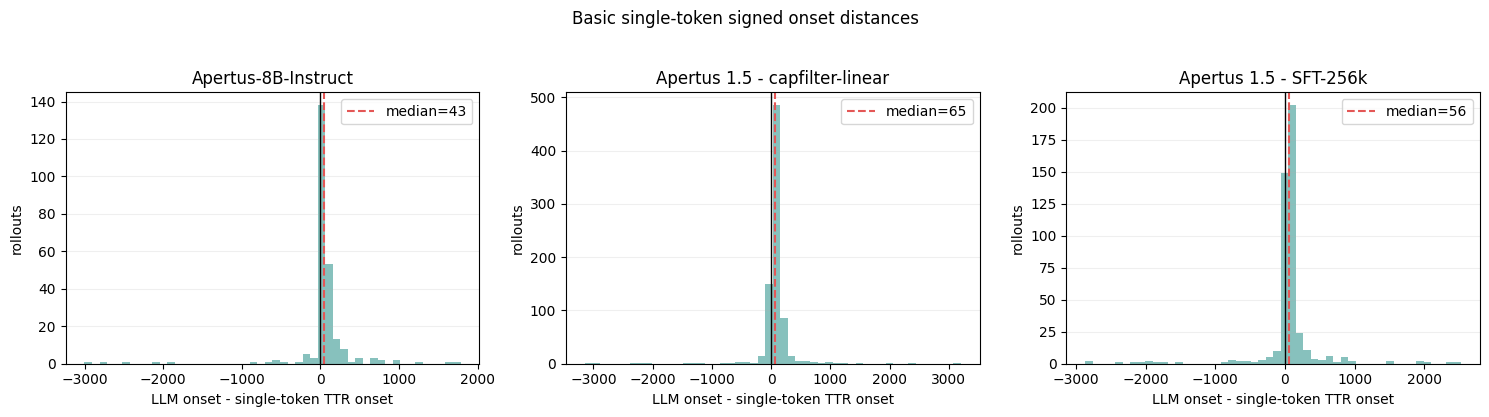

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (model, group) in zip(axes, single_onset_comparisons_df.groupby("dataset_build", sort=False)):
    values = group["signed_distance"].to_numpy()
    ax.hist(values, bins=50, color="#72b7b2", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(np.median(values), color="#e45756", linestyle="--", label=f"median={np.median(values):.0f}")
    ax.set_title(model)
    ax.set_xlabel("LLM onset - single-token TTR onset")
    ax.set_ylabel("rollouts")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Basic single-token signed onset distances", y=1.03)
plt.tight_layout()
plt.show()

## 6. Sustained run-4 TTR: onset study

This comparison is conditional on both methods providing an onset: the judge must be positive, its quote must be located, and TTR must contain a sustained four-token run. Judge-positive/TTR-negative rollouts are already counted as false negatives in the completion-level study and cannot contribute a finite onset distance.

In [11]:
onset_frames = []
onset_rows = []
for model, population in populations.items():
    comparable = population[
        population["is_degenerating"]
        & population["llm_onset"].notna()
        & population["ttr_run4_onset"].notna()
    ].copy()
    comparable["signed_distance"] = comparable["llm_onset"] - comparable["ttr_run4_onset"]
    comparable["absolute_distance"] = comparable["signed_distance"].abs()
    comparable["dataset_build"] = model
    onset_frames.append(comparable)

    d = comparable["signed_distance"]
    a = comparable["absolute_distance"]
    onset_rows.append({
        "dataset_build": model,
        "n_comparable": len(comparable),
        "mean_signed_distance": d.mean(),
        "median_signed_distance": d.median(),
        "mean_absolute_distance": a.mean(),
        "median_absolute_distance": a.median(),
        "q25_signed": d.quantile(0.25),
        "q75_signed": d.quantile(0.75),
        "judge_earlier_rate": (d < 0).mean(),
        "exact_rate": (d == 0).mean(),
        "judge_later_rate": (d > 0).mean(),
        "within_32_tokens": (a <= 32).mean(),
        "within_64_tokens": (a <= 64).mean(),
        "within_128_tokens": (a <= 128).mean(),
    })

run4_onset_comparisons_df = pd.concat(onset_frames, ignore_index=True)
run4_onset_summary_df = pd.DataFrame(onset_rows).set_index("dataset_build")
display(run4_onset_summary_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
    "q25_signed": "{:.1f}", "q75_signed": "{:.1f}",
    "judge_earlier_rate": "{:.1%}", "exact_rate": "{:.1%}",
    "judge_later_rate": "{:.1%}", "within_32_tokens": "{:.1%}",
    "within_64_tokens": "{:.1%}", "within_128_tokens": "{:.1%}",
}))

,n_comparable,mean_signed_distance,median_signed_distance,mean_absolute_distance,median_absolute_distance,q25_signed,q75_signed,judge_earlier_rate,exact_rate,judge_later_rate,within_32_tokens,within_64_tokens,within_128_tokens
dataset_build,,,,,,,,,,,,,
Apertus-8B-Instruct,244,44.6,43.5,164.2,51.0,8.0,89.2,9.8%,10.7%,79.5%,31.1%,59.8%,77.5%
Apertus 1.5 - capfilter-linear,795,67.6,65.0,144.5,73.0,32.0,115.5,9.6%,1.6%,88.8%,19.4%,44.8%,75.6%
Apertus 1.5 - SFT-256k,450,53.6,55.5,189.6,66.0,23.0,95.0,11.6%,3.1%,85.3%,23.6%,49.3%,75.6%


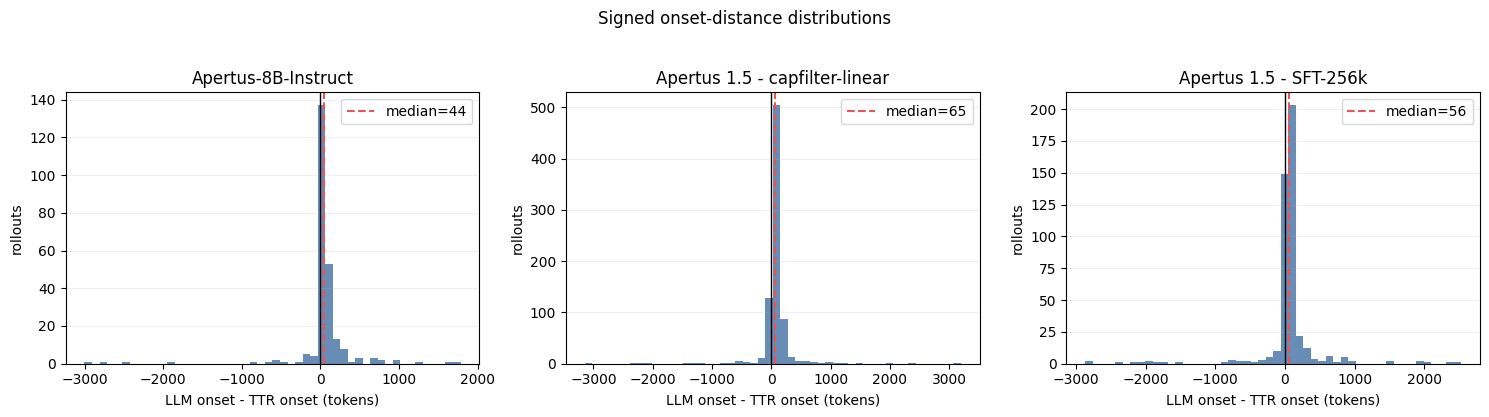

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (model, group) in zip(axes, run4_onset_comparisons_df.groupby("dataset_build", sort=False)):
    values = group["signed_distance"].to_numpy()
    ax.hist(values, bins=50, color="#4c78a8", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(np.median(values), color="#e45756", linestyle="--", label=f"median={np.median(values):.0f}")
    ax.set_title(model)
    ax.set_xlabel("LLM onset - TTR onset (tokens)")
    ax.set_ylabel("rollouts")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Signed onset-distance distributions", y=1.03)
plt.tight_layout()
plt.show()

### 6.1 Per-domain run-4 onset results

In [13]:
run4_domain_onset_df = (
    run4_onset_comparisons_df.groupby(["dataset_build", "domain"])["signed_distance"]
    .agg(
        n="size",
        mean_signed_distance="mean",
        median_signed_distance="median",
        mean_absolute_distance=lambda x: x.abs().mean(),
        median_absolute_distance=lambda x: x.abs().median(),
    )
)
display(run4_domain_onset_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
}))

### 6.2 Largest run-4 onset disagreements

These rows are useful for qualitative inspection. A large negative value means that the LLM judge identifies a substantially earlier first occurrence of the eventual pattern; a large positive value means that the sustained TTR rule fires substantially earlier.

In [14]:
example_columns = [
    "dataset_build", "domain", "prompt_id", "rollout_idx",
    "ttr_run4_onset", "llm_onset", "signed_distance", "onset_quote",
]
largest_disagreements = (
    run4_onset_comparisons_df.assign(abs_distance=lambda d: d["signed_distance"].abs())
    .sort_values("abs_distance", ascending=False)
    [example_columns]
    .head(20)
)
display(largest_disagreements)

,dataset_build,domain,prompt_id,rollout_idx,ttr_run4_onset,llm_onset,signed_distance,onset_quote
600,Apertus 1.5 - capfilter-linear,if_sft_data_verified,if_sft_data_verified_00490,8,553.0,3748.0,3195.0,We have f(n) = 2^n - 1.\n\nWe need to check if f(n) = 2^n - 1 satisfies the arithmetic sequence ...
269,Apertus 1.5 - capfilter-linear,codeforces,codeforces_00153,6,3470.0,325.0,-3145.0,vector<Point> sorted_x_y(N);\n for (int i = 0; i < N; ++i) {\n sorted_x_y[i] = Point(sorted_...
987,Apertus 1.5 - capfilter-linear,numinamath_1_5,numinamath_1_5_00480,8,3127.0,95.0,-3032.0,"The first few multiples of 36 are: 36, 72, 108, 144, 180, 216, 252, 288, 324, 360, 396, 432, 468..."
175,Apertus-8B-Instruct,llama_nemotron,llama_nemotron_00272,5,3240.0,236.0,-3004.0,end\n else\n move-up\n ...
1123,Apertus 1.5 - SFT-256k,deepmath_103k,deepmath_103k_00126,1,3338.0,468.0,-2870.0,= \frac{15-12\sqrt{2}}{2\sqrt{2}}\n= \frac{15-12\sqrt{2}}{2\sqrt{2}}\n= \frac{15-12\sqrt{2}}{2\s...
1405,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00024,4,3187.0,354.0,-2833.0,"Wait, let me re-calculate that."
174,Apertus-8B-Instruct,llama_nemotron,llama_nemotron_00248,2,3428.0,710.0,-2718.0,"Wait, but in the code, the DSU for each city is built as a dictionary where the key is the root ..."
1414,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00129,3,856.0,3386.0,2530.0,"This means $C'$ is the circumcenter of $\triangle AB'C'$? No, it's a point such that $AC' = AB'$..."
184,Apertus-8B-Instruct,llama_nemotron,llama_nemotron_00561,1,3016.0,545.0,-2471.0,"Wait, but in the code above, the BFS is not correctly implemented."
597,Apertus 1.5 - capfilter-linear,if_sft_data_verified,if_sft_data_verified_00490,2,498.0,2906.0,2408.0,uw = 3A + 2u - uv => uw = 3A + 2u - uv => uw = 3A + 2u - uv


## 7. Direct comparison: single-token vs. run-4

The single-token rule is logically less restrictive. Therefore every run-4 positive must also be single-token positive, and its onset cannot precede the first single threshold crossing. The checks below enforce these invariants before comparing detection and onset metrics.

In [15]:
flag_relation_rows = []
onset_delay_rows = []
for model, population in populations.items():
    assert not (population["ttr_run4_flag"] & ~population["ttr_single_flag"]).any()
    both = population["ttr_run4_flag"]
    assert (
        population.loc[both, "ttr_single_onset"]
        <= population.loc[both, "ttr_run4_onset"]
    ).all()
    flag_relation_rows.append({
        "dataset_build": model,
        "neither": int((~population["ttr_single_flag"]).sum()),
        "single_only": int((population["ttr_single_flag"] & ~population["ttr_run4_flag"]).sum()),
        "both": int(population["ttr_run4_flag"].sum()),
        "run4_only": int((population["ttr_run4_flag"] & ~population["ttr_single_flag"]).sum()),
    })
    delay = (
        population.loc[both, "ttr_run4_onset"]
        - population.loc[both, "ttr_single_onset"]
    )
    onset_delay_rows.append({
        "dataset_build": model,
        "n_both_ttr_positive": len(delay),
        "same_onset_rate": (delay == 0).mean(),
        "mean_run4_minus_single": delay.mean(),
        "median_run4_minus_single": delay.median(),
        "max_run4_minus_single": delay.max(),
    })

flag_relation_df = pd.DataFrame(flag_relation_rows).set_index("dataset_build")
onset_rule_delay_df = pd.DataFrame(onset_delay_rows).set_index("dataset_build")

comparison_metrics_df = pd.concat({
    "single-token": single_completion_metrics_df,
    "run-4": run4_completion_metrics_df,
}, names=["rule", "dataset_build"])
comparison_onset_df = pd.concat({
    "single-token": single_onset_summary_df,
    "run-4": run4_onset_summary_df,
}, names=["rule", "dataset_build"])

print("Flag relationship (run4_only must be zero)")
display(flag_relation_df)
print("Completion-level comparison")
display(comparison_metrics_df[[
    "n", "TP", "FP", "TN", "FN", "precision", "recall", "f1", "accuracy",
]].style.format({
    "precision": "{:.3f}", "recall": "{:.3f}",
    "f1": "{:.3f}", "accuracy": "{:.3f}",
}))
print("Onset comparison")
display(comparison_onset_df[[
    "n_comparable", "median_signed_distance", "median_absolute_distance",
    "within_64_tokens", "within_128_tokens",
]].style.format({
    "median_signed_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
    "within_64_tokens": "{:.1%}", "within_128_tokens": "{:.1%}",
}))
print("How much later the run-4 rule fires than the first threshold crossing")
display(onset_rule_delay_df.style.format({
    "same_onset_rate": "{:.1%}", "mean_run4_minus_single": "{:.1f}",
    "median_run4_minus_single": "{:.1f}", "max_run4_minus_single": "{:.0f}",
}))

Flag relationship (run4_only must be zero)


,neither,single_only,both,run4_only
dataset_build,,,,
Apertus-8B-Instruct,581,1,245,0
Apertus 1.5 - capfilter-linear,481,2,795,0
Apertus 1.5 - SFT-256k,659,1,451,0


Completion-level comparison


Onset comparison


How much later the run-4 rule fires than the first threshold crossing


,n_both_ttr_positive,same_onset_rate,mean_run4_minus_single,median_run4_minus_single,max_run4_minus_single
dataset_build,,,,,
Apertus-8B-Instruct,245,98.8%,0.2,0.0,18
Apertus 1.5 - capfilter-linear,795,98.5%,3.7,0.0,2233
Apertus 1.5 - SFT-256k,451,98.7%,0.8,0.0,264


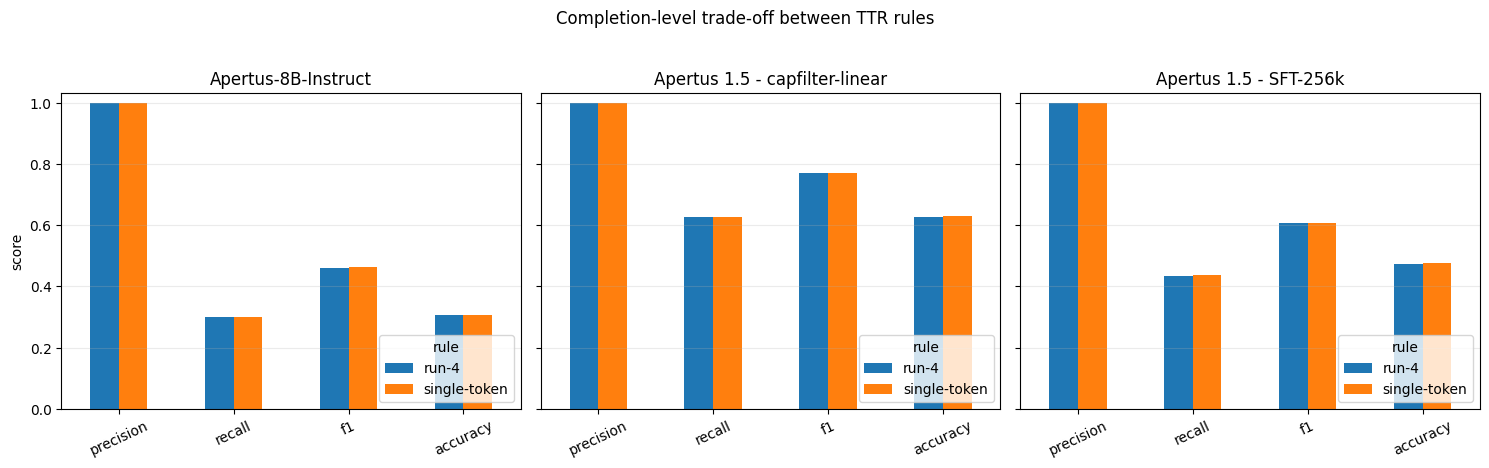

In [16]:
comparison_plot_df = (
    comparison_metrics_df[["precision", "recall", "accuracy", "f1"]]
    .reset_index()
    .melt(id_vars=["rule", "dataset_build"], var_name="metric", value_name="value")
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, model in zip(axes, DATASETS):
    sub = comparison_plot_df[comparison_plot_df["dataset_build"].eq(model)]
    pivot = sub.pivot(index="metric", columns="rule", values="value")
    pivot.loc[["precision", "recall", "f1", "accuracy"]].plot.bar(ax=ax, ylim=(0, 1.03))
    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("score")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="rule", loc="lower right")
fig.suptitle("Completion-level trade-off between TTR rules", y=1.03)
plt.tight_layout()
plt.show()

## 8. Paper-ready summary

In [17]:
summary_lines = [
    "We evaluate two TTR rules against the LLM judge on rollouts that reached the 4096-token generation cap without a natural EOS. The basic rule flags a generation after any single token with $1-\\mathrm{TTR}\geq0.8$; the sustained rule requires four consecutive threshold-positive positions. Completion-level results are:",
    "",
    "| Rule | Dataset build | Precision | Recall | Accuracy |",
    "|---|---|---:|---:|---:|",
]
for rule, table in [("single-token", single_completion_metrics_df), ("run-4", run4_completion_metrics_df)]:
    for model, row in table.iterrows():
        summary_lines.append(
            f"| {rule} | {model} | {row['precision']:.3f} | {row['recall']:.3f} | {row['accuracy']:.3f} |"
        )
summary_lines.extend([
    "",
    "The single-token rule is the more sensitive definition; the run-4 rule can only remove positive predictions, trading recall for protection against isolated threshold crossings. The exact trade-off is visible in the confusion counts and direct-comparison section above.",
    "",
    "On rollouts where the corresponding TTR rule provides an onset and the judge quote is found verbatim, the onset results are:",
    "",
    "| Rule | Dataset build | Comparable $n$ | Median signed distance | Median absolute distance |",
    "|---|---|---:|---:|---:|",
])
for rule, table in [("single-token", single_onset_summary_df), ("run-4", run4_onset_summary_df)]:
    for model, row in table.iterrows():
        summary_lines.append(
            f"| {rule} | {model} | {int(row['n_comparable'])} | {row['median_signed_distance']:.1f} tokens | {row['median_absolute_distance']:.1f} tokens |"
        )
summary_lines.extend([
    "",
    "Both TTR onset definitions remain forward-looking because each score at position $t$ summarizes the 256-token window beginning at $t$. Their comparison with the judge should therefore be interpreted as agreement between two operational onset definitions, not as error against an unquestionable timestamp.",
])
display(Markdown("\n".join(summary_lines)))

We evaluate two TTR rules against the LLM judge on rollouts that reached the 4096-token generation cap without a natural EOS. The basic rule flags a generation after any single token with $1-\mathrm{TTR}\geq0.8$; the sustained rule requires four consecutive threshold-positive positions. Completion-level results are:

| Rule | Dataset build | Precision | Recall | Accuracy |
|---|---|---:|---:|---:|
| single-token | Apertus-8B-Instruct | 1.000 | 0.300 | 0.307 |
| single-token | Apertus 1.5 - capfilter-linear | 1.000 | 0.627 | 0.628 |
| single-token | Apertus 1.5 - SFT-256k | 0.998 | 0.437 | 0.475 |
| run-4 | Apertus-8B-Instruct | 1.000 | 0.299 | 0.306 |
| run-4 | Apertus 1.5 - capfilter-linear | 1.000 | 0.625 | 0.627 |
| run-4 | Apertus 1.5 - SFT-256k | 0.998 | 0.436 | 0.474 |

The single-token rule is the more sensitive definition; the run-4 rule can only remove positive predictions, trading recall for protection against isolated threshold crossings. The exact trade-off is visible in the confusion counts and direct-comparison section above.

On rollouts where the corresponding TTR rule provides an onset and the judge quote is found verbatim, the onset results are:

| Rule | Dataset build | Comparable $n$ | Median signed distance | Median absolute distance |
|---|---|---:|---:|---:|
| single-token | Apertus-8B-Instruct | 245 | 43.0 tokens | 51.0 tokens |
| single-token | Apertus 1.5 - capfilter-linear | 797 | 65.0 tokens | 73.0 tokens |
| single-token | Apertus 1.5 - SFT-256k | 451 | 56.0 tokens | 66.0 tokens |
| run-4 | Apertus-8B-Instruct | 244 | 43.5 tokens | 51.0 tokens |
| run-4 | Apertus 1.5 - capfilter-linear | 795 | 65.0 tokens | 73.0 tokens |
| run-4 | Apertus 1.5 - SFT-256k | 450 | 55.5 tokens | 66.0 tokens |

Both TTR onset definitions remain forward-looking because each score at position $t$ summarizes the 256-token window beginning at $t$. Their comparison with the judge should therefore be interpreted as agreement between two operational onset definitions, not as error against an unquestionable timestamp.

## 9. Interpretation notes

- The completion-level tables and onset tables answer different questions and have different denominators. Binary evaluation uses every successfully judged capped rollout in the current calibration sample. Onset evaluation is conditional on a matched judge quote and a positive flag from the rule being evaluated.
- The capped-rollout population is intentionally enriched for degeneration. Precision and recall are directly meaningful on this population, but accuracy largely follows recall because judge-positive prevalence is high; specificity may be unstable when there are few judge-negative rows.
- The TTR label at position $t$ summarizes the 256-token window starting at $t$. Therefore, the TTR onset is a forward-looking warning position, whereas the judge is instructed to mark the first occurrence of the pattern that later repeats. A systematic signed offset can reflect this difference in semantics rather than simple localization error.
- The single-token rule follows the simplest interpretation of a token-level label and maximizes sensitivity to threshold crossings. The run-4 rule removes isolated spikes but does not guarantee semantic degeneration. Legitimate repetitive structures can still generate false positives, while evolving templates can produce false negatives.
- Failed judge calls and judge-positive rows without a verifiably locatable quote are reported as coverage losses, not silently treated as negative labels.